# HYPERVIEW2 Compression Downstream Evaluation

Jeden notebook do pelnej walidacji downstream dla kompresji HYPERVIEW2:

1. przygotowuje repo, zaleznosci, Google Drive i dataset,
2. wykorzystuje zapisane rekonstrukcje lub opcjonalnie generuje nowe z checkpointow,
3. uruchamia regresory na oryginale i rekonstrukcjach,
4. zapisuje CSV/JSON z wynikami,
5. pokazuje interaktywne diagnostyki: score, targety, predykcje, pasma i widma.

Domyslny preset uzywa teraz HySpecNet-compatible normalizacji `reflectance_0_1`: raw reflectance w [0, 1], invalid pixels = 0, bez per-sample percentile stretch.

Wyniki sa diagnostyka transferu na HYPERVIEW2, a nie reference-comparable metrykami HySpecNet-11k.

## 1. Repo

In [23]:
from pathlib import Path
import os
import subprocess
import sys

REPO_URL = 'https://github.com/mhx1467/master-thesis-code.git'
REPO_DIR = Path('/content/hsi')
REPO_REF = 'main'

if not REPO_DIR.exists():
    subprocess.run(['git', 'clone', REPO_URL, str(REPO_DIR)], check=True)
subprocess.run(['git', 'fetch', 'origin'], cwd=REPO_DIR, check=True)
subprocess.run(['git', 'checkout', REPO_REF], cwd=REPO_DIR, check=True)
subprocess.run(['git', 'pull', '--ff-only'], cwd=REPO_DIR, check=True)

for module_name in list(sys.modules):
    if module_name == 'hsi_compression' or module_name.startswith('hsi_compression.'):
        del sys.modules[module_name]

os.chdir(REPO_DIR)
print('Repo:', Path.cwd())
print('Git:', subprocess.check_output(['git', 'rev-parse', '--short', 'HEAD'], text=True).strip())

Repo: /content/hsi
Git: 9ce6a6b


## 2. Zaleznosci

In [24]:
# Main switch. Default mode evaluates already saved reconstructions from Drive and does
# not need mamba-ssm. Set RUN_RECONSTRUCTION=True only when you want this notebook to
# generate new Mamba reconstructions from checkpoints inside Colab.
RUN_RECONSTRUCTION = True
INSTALL_MAMBA = RUN_RECONSTRUCTION
INSTALL_OPTIONAL_BOOSTING = False
FORCE_REINSTALL_ENV = False

from pathlib import Path
import os
import subprocess
import sys

PIP = [sys.executable, '-m', 'pip']
marker_name = '.hsi_compression_colab_env_v3_mamba' if INSTALL_MAMBA else '.hsi_compression_colab_env_v3_basic'
ENV_MARKER = Path('/content') / marker_name


def run_install(cmd, *, required=True):
    print('Running:', ' '.join(cmd))
    result = subprocess.run(
        cmd,
        check=False,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
    )
    if result.stdout:
        print(result.stdout[-6000:])
    if result.returncode != 0:
        message = f'Command failed with exit code {result.returncode}: {" ".join(cmd)}'
        if required:
            raise RuntimeError(message)
        print('Optional install skipped:', message)
        return False
    return True


if FORCE_REINSTALL_ENV and ENV_MARKER.exists():
    ENV_MARKER.unlink()

if not ENV_MARKER.exists():
    base_install_cmds = [
        PIP + ['install', '-q', '--upgrade', 'pip', 'setuptools', 'wheel', 'pybind11', 'ninja'],
        PIP + [
            'install', '-q', '--upgrade', '--force-reinstall',
            'numpy==1.26.4',
            'pandas>=2.2,<2.3',
            'scipy>=1.12,<1.15',
            'scikit-learn>=1.4,<1.6',
        ],
        PIP + ['install', '-q', '-e', '.[downstream]', 'eotdl', 'tqdm', 'matplotlib', 'ipywidgets'],
    ]
    for cmd in base_install_cmds:
        run_install(cmd, required=True)

    if INSTALL_MAMBA:
        mamba_ok = True
        for cmd in [
            PIP + ['install', '--no-build-isolation', 'causal-conv1d>=1.4.0'],
            PIP + ['install', '--no-build-isolation', 'mamba-ssm>=2.3.1'],
        ]:
            mamba_ok = run_install(cmd, required=False) and mamba_ok
            if not mamba_ok:
                break
        if not mamba_ok:
            raise RuntimeError(
                'Colab could not install causal-conv1d/mamba-ssm for this runtime. '
                'Set RUN_RECONSTRUCTION=False to evaluate saved reconstructions from Drive, '
                'or generate reconstructions on the remote GPU and rerun this notebook in analysis mode.'
            )

    if INSTALL_OPTIONAL_BOOSTING:
        run_install(PIP + ['install', '-q', 'lightgbm', 'catboost', 'xgboost'], required=True)

    ENV_MARKER.write_text('installed\n', encoding='utf-8')
    print('Dependencies installed. Colab runtime will restart once to reload NumPy ABI.')
    print('After reconnect, rerun from the repo cell; this cell will skip reinstalling.')
    os.kill(os.getpid(), 9)
else:
    print('Dependency marker exists, skipping reinstall:', ENV_MARKER)

import numpy as np
import torch

print('Python:', sys.version)
print('NumPy:', np.__version__)
print('Torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
elif RUN_RECONSTRUCTION:
    raise RuntimeError('RUN_RECONSTRUCTION=True requires a GPU runtime.')

MAMBA_AVAILABLE = False
if INSTALL_MAMBA:
    try:
        from mamba_ssm import Mamba
        MAMBA_AVAILABLE = True
        print('mamba-ssm import: ok')
    except Exception as exc:
        raise RuntimeError(
            'mamba-ssm is required only for generating new Mamba reconstructions in Colab. '
            'Set RUN_RECONSTRUCTION=False to evaluate saved reconstructions.'
        ) from exc
else:
    print('Mamba install skipped; notebook will use saved reconstructions from Drive.')

Dependency marker exists, skipping reinstall: /content/.hsi_compression_colab_env_v3_basic
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
NumPy: 1.26.4
Torch: 2.10.0+cpu
CUDA available: False
Mamba install skipped; notebook will use saved reconstructions from Drive.


## 3. Drive, dataset i katalogi wynikow

In [25]:
from pathlib import Path
import subprocess
import sys
from google.colab import drive

drive.mount('/content/drive')

DRIVE_HSI = Path('/content/drive/MyDrive/hsi')
DRIVE_DATA_PARENT = DRIVE_HSI / 'data/hyperview2'
DRIVE_HV2_ROOT = DRIVE_DATA_PARENT / 'HYPERVIEW2'
DRIVE_DATA_ARCHIVE = DRIVE_DATA_PARENT / 'HYPERVIEW2_20260525.tar.gz'
DRIVE_CHECKPOINTS = DRIVE_HSI / 'checkpoints'
DRIVE_RECONS = DRIVE_HSI / 'reconstructions/hyperview2'
DRIVE_RESULTS = DRIVE_HSI / 'downstream_results/hyperview2_compression_hyspecnet_norm'

for path in [DRIVE_DATA_PARENT, DRIVE_CHECKPOINTS, DRIVE_RECONS, DRIVE_RESULTS]:
    path.mkdir(parents=True, exist_ok=True)

LOCAL_DATA_PARENT = Path('/content/data/hyperview2')
LOCAL_DATA_PARENT.mkdir(parents=True, exist_ok=True)


def is_hyperview2_root(path: Path) -> bool:
    required = [
        path / 'train_gt.csv',
        path / 'submission.csv',
        path / 'train/hsi_satellite',
        path / 'test/hsi_satellite',
    ]
    return all(item.exists() for item in required)


def find_hyperview2_root(search_root: Path) -> Path | None:
    if is_hyperview2_root(search_root):
        return search_root
    for candidate in sorted(search_root.rglob('HYPERVIEW2')) if search_root.exists() else []:
        if is_hyperview2_root(candidate):
            return candidate
    return None


HV2_ROOT = find_hyperview2_root(DRIVE_DATA_PARENT)
if HV2_ROOT is None and DRIVE_DATA_ARCHIVE.exists():
    print('Extracting HYPERVIEW2 archive from Drive:', DRIVE_DATA_ARCHIVE)
    subprocess.run(['tar', '-xzf', str(DRIVE_DATA_ARCHIVE), '-C', str(DRIVE_DATA_PARENT)], check=True)
    HV2_ROOT = find_hyperview2_root(DRIVE_DATA_PARENT)

if HV2_ROOT is None:
    print('Dataset not found on Drive. Downloading with EOTDL to local Colab storage...')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'eotdl'], check=True)
    subprocess.run(['eotdl', 'datasets', 'get', 'HYPERVIEW2', '-o', str(LOCAL_DATA_PARENT)], check=True)
    HV2_ROOT = find_hyperview2_root(LOCAL_DATA_PARENT)

if HV2_ROOT is None or not is_hyperview2_root(HV2_ROOT):
    raise FileNotFoundError('Could not resolve canonical HYPERVIEW2 root.')

print('HV2_ROOT:', HV2_ROOT)
for rel in ['train/hsi_satellite', 'train/hsi_airborne', 'train/msi_satellite', 'test/hsi_satellite', 'test/msi_satellite']:
    directory = HV2_ROOT / rel
    count = len(list(directory.glob('*.npz'))) if directory.exists() else 0
    print(f'{rel:24s} {count:5d} npz files')
print('Checkpoints:', DRIVE_CHECKPOINTS)
print('Reconstructions:', DRIVE_RECONS)
print('Results:', DRIVE_RESULTS)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
HV2_ROOT: /content/drive/MyDrive/hsi/data/hyperview2/HYPERVIEW2
train/hsi_satellite       1876 npz files
train/hsi_airborne        1876 npz files
train/msi_satellite       1876 npz files
test/hsi_satellite        1888 npz files
test/msi_satellite        1888 npz files
Checkpoints: /content/drive/MyDrive/hsi/checkpoints
Reconstructions: /content/drive/MyDrive/hsi/reconstructions/hyperview2
Results: /content/drive/MyDrive/hsi/downstream_results/hyperview2_compression_hyspecnet_norm


## 4. Konfiguracja eksperymentu

In [26]:
from pathlib import Path
from typing import Any
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from tqdm.auto import tqdm

from hsi_compression.downstream import HYPERVIEW2_TARGET_COLUMNS, build_hyperview2_samples, split_samples
from hsi_compression.downstream.hyperview2_compression_eval import (
    CompressionCheckpoint,
    best_by_variant_mode,
    compute_per_band_diagnostics,
    discover_recon_roots,
    evaluate_downstream_regressors,
    infer_recon_input_normalization,
    load_cube_and_value_mask,
    normalize_original_cube,
    prediction_metrics_by_target,
    prediction_shift_decomposition,
    read_reconstruction_summary,
    reconstruct_checkpoint,
    safe_sample_stem,
    sample_path,
    save_downstream_artifacts,
)

plt.rcParams['figure.dpi'] = 130
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TARGETS = list(HYPERVIEW2_TARGET_COLUMNS)

MODALITY = 'prisma'
FEATURE_SET = 'mean_std_derivatives'
ORIGINAL_FEATURE_NORMALIZATION = 'reflectance_0_1'
CHECKPOINT_NORMALIZATION_FALLBACK = 'reflectance_0_1'
VAL_FRACTION = 0.2
SEED = 42
N_JOBS = -1

# Fast default: strongest regressors from the previous HYPERVIEW2 sweeps.
# Add 'dummy_mean', 'ridge', 'pls', or 'knn' back for a full baseline table.
MODEL_NAMES = [
    'hist_gradient_boosting',
    'extra_trees',
    'random_forest',
]

FORCE_RECONSTRUCTION = True
AUTO_DISCOVER_RECONS = False
RECOMPUTE_REGRESSORS = True     # train/evaluate regressors again; set False only to load cached CSV/JSON
ADD_LOSSLESS_PASSTHROUGH = True  # exact-reconstruction sanity upper bound; does not run TCN bitstream
MAX_PER_BAND_SAMPLES = None      # set e.g. 300 for faster diagnostics
VARIANTS_TO_EVALUATE: list[str] | str = 'auto'  # or list of variant names

# HySpecNet-compatible transfer preset: raw reflectance in [0, 1], invalid pixels zeroed.
# Previous percentile reconstructions are still auto-discovered as controls when present.
SPECTRAL_FEATURE_CKPT = DRIVE_CHECKPOINTS / 'hierarchical_spectral_mamba_ae_k4_spatial_rd_lambda_0_001_spectral_feature_ft_best.pt'
CHECKPOINTS = []
if RUN_RECONSTRUCTION and SPECTRAL_FEATURE_CKPT.exists():
    CHECKPOINTS.append(CompressionCheckpoint(
        name='mamba_k4_spectral_feature_ft_reflectance',
        path=SPECTRAL_FEATURE_CKPT,
        variant_name='hyperview2_mamba_k4_spectral_feature_ft_epoch16_input_reflectance_0_1',
        compression_normalization='reflectance_0_1',
        recon_feature_normalization='none',
        batch_size=1,
        num_workers=2,
        use_bitstream=True,
        allow_in_channel_adapter=True,
    ))
elif RUN_RECONSTRUCTION:
    print('No checkpoint configured because file is missing:', SPECTRAL_FEATURE_CKPT)

print('Device:', DEVICE)
print('Checkpoints to reconstruct:', [ckpt.name for ckpt in CHECKPOINTS])

Device: cpu
Checkpoints to reconstruct: []


## 5. Rekonstrukcje: wygeneruj lub uzyj zapisanych

In [27]:
reconstruction_summaries: dict[str, Any] = {}
RECON_ROOTS: dict[str, Path] = {}
RECON_INPUT_NORMALIZATIONS: dict[str, str] = {}
RECON_FEATURE_NORMALIZATIONS: dict[str, str] = {}

if AUTO_DISCOVER_RECONS:
    for variant, root in discover_recon_roots(DRIVE_RECONS).items():
        summary = read_reconstruction_summary(root)
        RECON_ROOTS[variant] = root
        RECON_INPUT_NORMALIZATIONS[variant] = infer_recon_input_normalization(variant, summary)
        RECON_FEATURE_NORMALIZATIONS[variant] = str((summary or {}).get('recon_feature_normalization', 'none'))
        if summary:
            reconstruction_summaries[variant] = summary

if ADD_LOSSLESS_PASSTHROUGH:
    variant = 'lossless_passthrough_exact'
    RECON_ROOTS[variant] = HV2_ROOT
    RECON_INPUT_NORMALIZATIONS[variant] = ORIGINAL_FEATURE_NORMALIZATION
    RECON_FEATURE_NORMALIZATIONS[variant] = ORIGINAL_FEATURE_NORMALIZATION
    reconstruction_summaries[variant] = {
        'variant': variant,
        'recon_root': str(HV2_ROOT),
        'note': 'Exact reconstruction sanity upper bound; no codec bitstream generated in this notebook.',
    }

for checkpoint in CHECKPOINTS:
    variant = checkpoint.variant_name or f'{checkpoint.name}_input_{checkpoint.compression_normalization}'
    expected_root = DRIVE_RECONS / variant / 'HYPERVIEW2'
    if expected_root.exists() and not FORCE_RECONSTRUCTION:
        print('Using existing reconstruction:', variant, '->', expected_root)
        summary = read_reconstruction_summary(expected_root) or {}
    else:
        expected_root, summary = reconstruct_checkpoint(
            checkpoint,
            source_root=HV2_ROOT,
            recon_parent=DRIVE_RECONS,
            device=DEVICE,
            checkpoint_normalization_fallback=CHECKPOINT_NORMALIZATION_FALLBACK,
            split='train',
        )
    RECON_ROOTS[variant] = expected_root
    RECON_INPUT_NORMALIZATIONS[variant] = str(summary.get('input_normalization', checkpoint.compression_normalization))
    RECON_FEATURE_NORMALIZATIONS[variant] = checkpoint.recon_feature_normalization
    reconstruction_summaries[variant] = summary

if VARIANTS_TO_EVALUATE != 'auto':
    selected = set(VARIANTS_TO_EVALUATE)
    RECON_ROOTS = {name: root for name, root in RECON_ROOTS.items() if name in selected}
    RECON_INPUT_NORMALIZATIONS = {name: RECON_INPUT_NORMALIZATIONS[name] for name in RECON_ROOTS}
    RECON_FEATURE_NORMALIZATIONS = {name: RECON_FEATURE_NORMALIZATIONS[name] for name in RECON_ROOTS}

print('Variants used for downstream evaluation:')
for name, root in RECON_ROOTS.items():
    print(
        ' ', name,
        '| root=', root,
        '| input_norm=', RECON_INPUT_NORMALIZATIONS.get(name),
        '| feature_norm=', RECON_FEATURE_NORMALIZATIONS.get(name),
    )
if not RECON_ROOTS:
    print('No reconstruction variants found. Add CHECKPOINTS or place reconstructions under Drive.')

Variants used for downstream evaluation:
  hyperview2_mamba_k4_spectral_feature_ft_epoch16_input_percentile | root= /content/drive/MyDrive/hsi/reconstructions/hyperview2/hyperview2_mamba_k4_spectral_feature_ft_epoch16_input_percentile/HYPERVIEW2 | input_norm= percentile | feature_norm= none
  hyperview2_mamba_latent48 | root= /content/drive/MyDrive/hsi/reconstructions/hyperview2/hyperview2_mamba_latent48/HYPERVIEW2 | input_norm= none | feature_norm= none
  hyperview2_mamba_latent48_input_percentile | root= /content/drive/MyDrive/hsi/reconstructions/hyperview2/hyperview2_mamba_latent48_input_percentile/HYPERVIEW2 | input_norm= percentile | feature_norm= none
  lossless_passthrough_exact | root= /content/drive/MyDrive/hsi/data/hyperview2/HYPERVIEW2 | input_norm= reflectance_0_1 | feature_norm= reflectance_0_1


## 6. Ewaluacja regresorow

In [28]:
cached_paths = {
    'summary_csv': DRIVE_RESULTS / 'compression_downstream_summary.csv',
    'predictions_csv': DRIVE_RESULTS / 'compression_downstream_predictions.csv',
    'metrics_json': DRIVE_RESULTS / 'compression_downstream_metrics.json',
}
cache_available = all(path.exists() for path in cached_paths.values())

if RECOMPUTE_REGRESSORS or not cache_available:
    print('Training/evaluating downstream regressors from scratch...')
    results_df, predictions_df, metrics_payload = evaluate_downstream_regressors(
        hv2_root=HV2_ROOT,
        recon_roots=RECON_ROOTS,
        recon_feature_normalizations=RECON_FEATURE_NORMALIZATIONS,
        model_names=MODEL_NAMES,
        modality=MODALITY,
        feature_set=FEATURE_SET,
        original_feature_normalization=ORIGINAL_FEATURE_NORMALIZATION,
        val_fraction=VAL_FRACTION,
        seed=SEED,
        n_jobs=N_JOBS,
    )
    metrics_payload['reconstruction_summaries'] = reconstruction_summaries
    metrics_payload['protocol']['recon_input_normalizations'] = RECON_INPUT_NORMALIZATIONS
    metrics_payload['protocol']['checkpoints'] = [ckpt.to_record() for ckpt in CHECKPOINTS]

    paths = save_downstream_artifacts(DRIVE_RESULTS, results_df, predictions_df, metrics_payload)
    for label, path in paths.items():
        print(label, '->', path)
else:
    print('Loading cached downstream results. Set RECOMPUTE_REGRESSORS=True to retrain.')
    results_df = pd.read_csv(cached_paths['summary_csv'])
    predictions_df = pd.read_csv(cached_paths['predictions_csv'])
    metrics_payload = json.loads(cached_paths['metrics_json'].read_text())

best_df = best_by_variant_mode(results_df)
display(best_df[['variant', 'mode', 'model', 'hyperview_score', 'mean_mse', 'mean_mae', 'fit_time_sec', 'predict_time_sec']])


Training/evaluating downstream regressors from scratch...


features:prisma:reflectance_0_1:mean_std_derivatives:   0%|          | 0/1501 [00:00<?, ?it/s]

features:prisma:reflectance_0_1:mean_std_derivatives:   0%|          | 0/375 [00:00<?, ?it/s]

features:prisma:none:mean_std_derivatives:   0%|          | 0/1501 [00:00<?, ?it/s]

features:prisma:none:mean_std_derivatives:   0%|          | 0/375 [00:00<?, ?it/s]

...

features:prisma:none:mean_std_derivatives:   0%|          | 0/375 [00:00<?, ?it/s]

features:prisma:reflectance_0_1:mean_std_derivatives:   0%|          | 0/1501 [00:00<?, ?it/s]

features:prisma:reflectance_0_1:mean_std_derivatives:   0%|          | 0/375 [00:00<?, ?it/s]

summary_csv -> /content/drive/MyDrive/hsi/downstream_results/hyperview2_compression_hyspecnet_norm/compression_downstream_summary.csv
predictions_csv -> /content/drive/MyDrive/hsi/downstream_results/hyperview2_compression_hyspecnet_norm/compression_downstream_predictions.csv
metrics_json -> /content/drive/MyDrive/hsi/downstream_results/hyperview2_compression_hyspecnet_norm/compression_downstream_metrics.json


,variant,mode,model,hyperview_score,mean_mse,mean_mae,fit_time_sec,predict_time_sec
0,hyperview2_mamba_k4_spectral_feature_ft_epoch1...,original_train_to_recon_val,extra_trees,1.087555,705.686096,12.707085,3.088821,0.097521
1,hyperview2_mamba_k4_spectral_feature_ft_epoch1...,recon_train_to_recon_val,extra_trees,0.773197,473.952637,9.816878,3.307810,0.106275
2,hyperview2_mamba_latent48,original_train_to_recon_val,extra_trees,1.209186,714.134521,12.789448,3.147965,0.095810
3,hyperview2_mamba_latent48,recon_train_to_recon_val,random_forest,0.801551,511.223846,10.104525,7.181796,0.074685
4,hyperview2_mamba_latent48_input_percentile,original_train_to_recon_val,random_forest,1.130950,665.237793,12.123581,12.281775,0.085622
5,hyperview2_mamba_latent48_input_percentile,recon_train_to_recon_val,random_forest,0.791777,488.850739,9.950169,13.418574,0.084803
6,lossless_passthrough_exact,original_train_to_recon_val,hist_gradient_boosting,0.537786,348.052582,8.396620,129.788856,0.752270
7,lossless_passthrough_exact,recon_train_to_recon_val,hist_gradient_boosting,0.537786,348.052582,8.396620,130.311946,1.506039
8,original,original_train_to_original_val,hist_gradient_boosting,0.537786,348.052582,8.396620,135.940693,0.758561


## 7. Szybkie podsumowanie wynikow

Saved: /content/drive/MyDrive/hsi/downstream_results/hyperview2_compression_hyspecnet_norm/best_scores.csv


,variant,mode,model,hyperview_score,ratio_to_original_best
0,hyperview2_mamba_k4_spectral_feature_ft_epoch1...,original_train_to_recon_val,extra_trees,1.087555,2.022282
1,hyperview2_mamba_k4_spectral_feature_ft_epoch1...,recon_train_to_recon_val,extra_trees,0.773197,1.437741
2,hyperview2_mamba_latent48,original_train_to_recon_val,extra_trees,1.209186,2.248452
3,hyperview2_mamba_latent48,recon_train_to_recon_val,random_forest,0.801551,1.490464
4,hyperview2_mamba_latent48_input_percentile,original_train_to_recon_val,random_forest,1.130950,2.102973
5,hyperview2_mamba_latent48_input_percentile,recon_train_to_recon_val,random_forest,0.791777,1.472290
6,lossless_passthrough_exact,original_train_to_recon_val,hist_gradient_boosting,0.537786,1.000000
7,lossless_passthrough_exact,recon_train_to_recon_val,hist_gradient_boosting,0.537786,1.000000
8,original,original_train_to_original_val,hist_gradient_boosting,0.537786,1.000000


/tmp/ipykernel_1168/2661248896.py:21: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


Saved: /content/drive/MyDrive/hsi/downstream_results/hyperview2_compression_hyspecnet_norm/best_downstream_scores.png


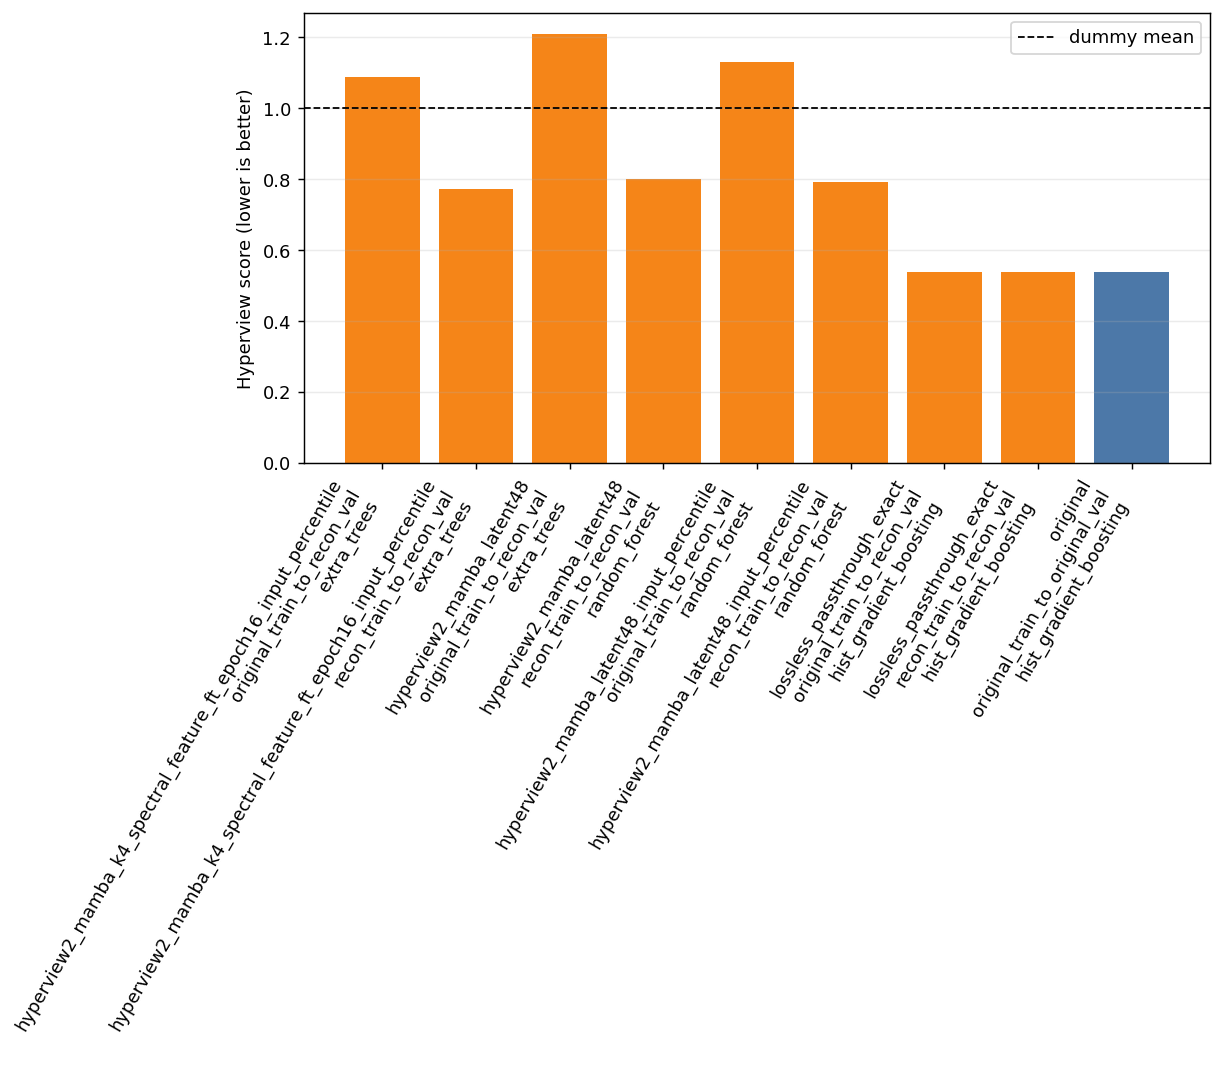

In [29]:
best_df = best_by_variant_mode(results_df)
original_score = best_df.loc[best_df['variant'].eq('original'), 'hyperview_score'].min()
summary = best_df.copy()
summary['ratio_to_original_best'] = summary['hyperview_score'] / original_score
summary_path = DRIVE_RESULTS / 'best_scores.csv'
summary.to_csv(summary_path, index=False)
print('Saved:', summary_path)
display(summary[['variant', 'mode', 'model', 'hyperview_score', 'ratio_to_original_best']])

plot_df = summary.sort_values(['variant', 'mode']).copy()
labels = plot_df['variant'] + '\n' + plot_df['mode'] + '\n' + plot_df['model']
fig, ax = plt.subplots(figsize=(max(9, 0.55 * len(plot_df)), 4.5))
colors = ['#4c78a8' if row.variant == 'original' else '#f58518' for row in plot_df.itertuples()]
ax.bar(np.arange(len(plot_df)), plot_df['hyperview_score'], color=colors)
ax.axhline(1.0, color='black', linewidth=1, linestyle='--', label='dummy mean')
ax.set_ylabel('Hyperview score (lower is better)')
ax.set_xticks(np.arange(len(plot_df)))
ax.set_xticklabels(labels, rotation=60, ha='right')
ax.grid(True, axis='y', alpha=0.25)
ax.legend(loc='upper right')
fig.tight_layout()
out = DRIVE_RESULTS / 'best_downstream_scores.png'
fig.savefig(out, bbox_inches='tight')
print('Saved:', out)
plt.show()

## 8. Targety i przesuniecie predykcji

Saved: /content/drive/MyDrive/hsi/downstream_results/hyperview2_compression_hyspecnet_norm/prediction_metrics_by_target.csv
Saved: /content/drive/MyDrive/hsi/downstream_results/hyperview2_compression_hyspecnet_norm/prediction_shift_decomposition.csv


,variant,mode,model,target,samples,bias,mae,mse,relative_mse,rmse
0,hyperview2_mamba_k4_spectral_feature_ft_epoch1...,original_train_to_recon_val,extra_trees,Cu,375,-0.000765,0.327744,0.188851,0.992053,0.434570
1,hyperview2_mamba_k4_spectral_feature_ft_epoch1...,original_train_to_recon_val,extra_trees,Mn,375,-5.130822,17.770170,522.965100,0.998109,22.868430
2,hyperview2_mamba_k4_spectral_feature_ft_epoch1...,original_train_to_recon_val,extra_trees,Fe,375,16.581054,45.946984,3499.636519,1.076274,59.157726
3,hyperview2_mamba_k4_spectral_feature_ft_epoch1...,original_train_to_recon_val,extra_trees,Zn,375,0.669623,1.730683,4.388362,1.121100,2.094842
4,hyperview2_mamba_k4_spectral_feature_ft_epoch1...,original_train_to_recon_val,extra_trees,B,375,0.103002,0.205276,0.061421,1.166279,0.247833
5,hyperview2_mamba_k4_spectral_feature_ft_epoch1...,original_train_to_recon_val,extra_trees,S,375,-5.708797,10.261647,206.877189,1.171516,14.383226
6,hyperview2_mamba_k4_spectral_feature_ft_epoch1...,recon_train_to_recon_val,extra_trees,B,375,0.005887,0.146253,0.035714,0.678148,0.188982
7,hyperview2_mamba_k4_spectral_feature_ft_epoch1...,recon_train_to_recon_val,extra_trees,Fe,375,-0.809763,34.614415,2319.787286,0.713425,48.164170
8,hyperview2_mamba_k4_spectral_feature_ft_epoch1...,recon_train_to_recon_val,extra_trees,S,375,-0.477384,7.820321,130.187559,0.737233,11.409976
9,hyperview2_mamba_k4_spectral_feature_ft_epoch1...,recon_train_to_recon_val,extra_trees,Mn,375,-2.379756,14.709081,390.239946,0.744796,19.754492


Saved: /content/drive/MyDrive/hsi/downstream_results/hyperview2_compression_hyspecnet_norm/per_target_relative_mse_best_models.png


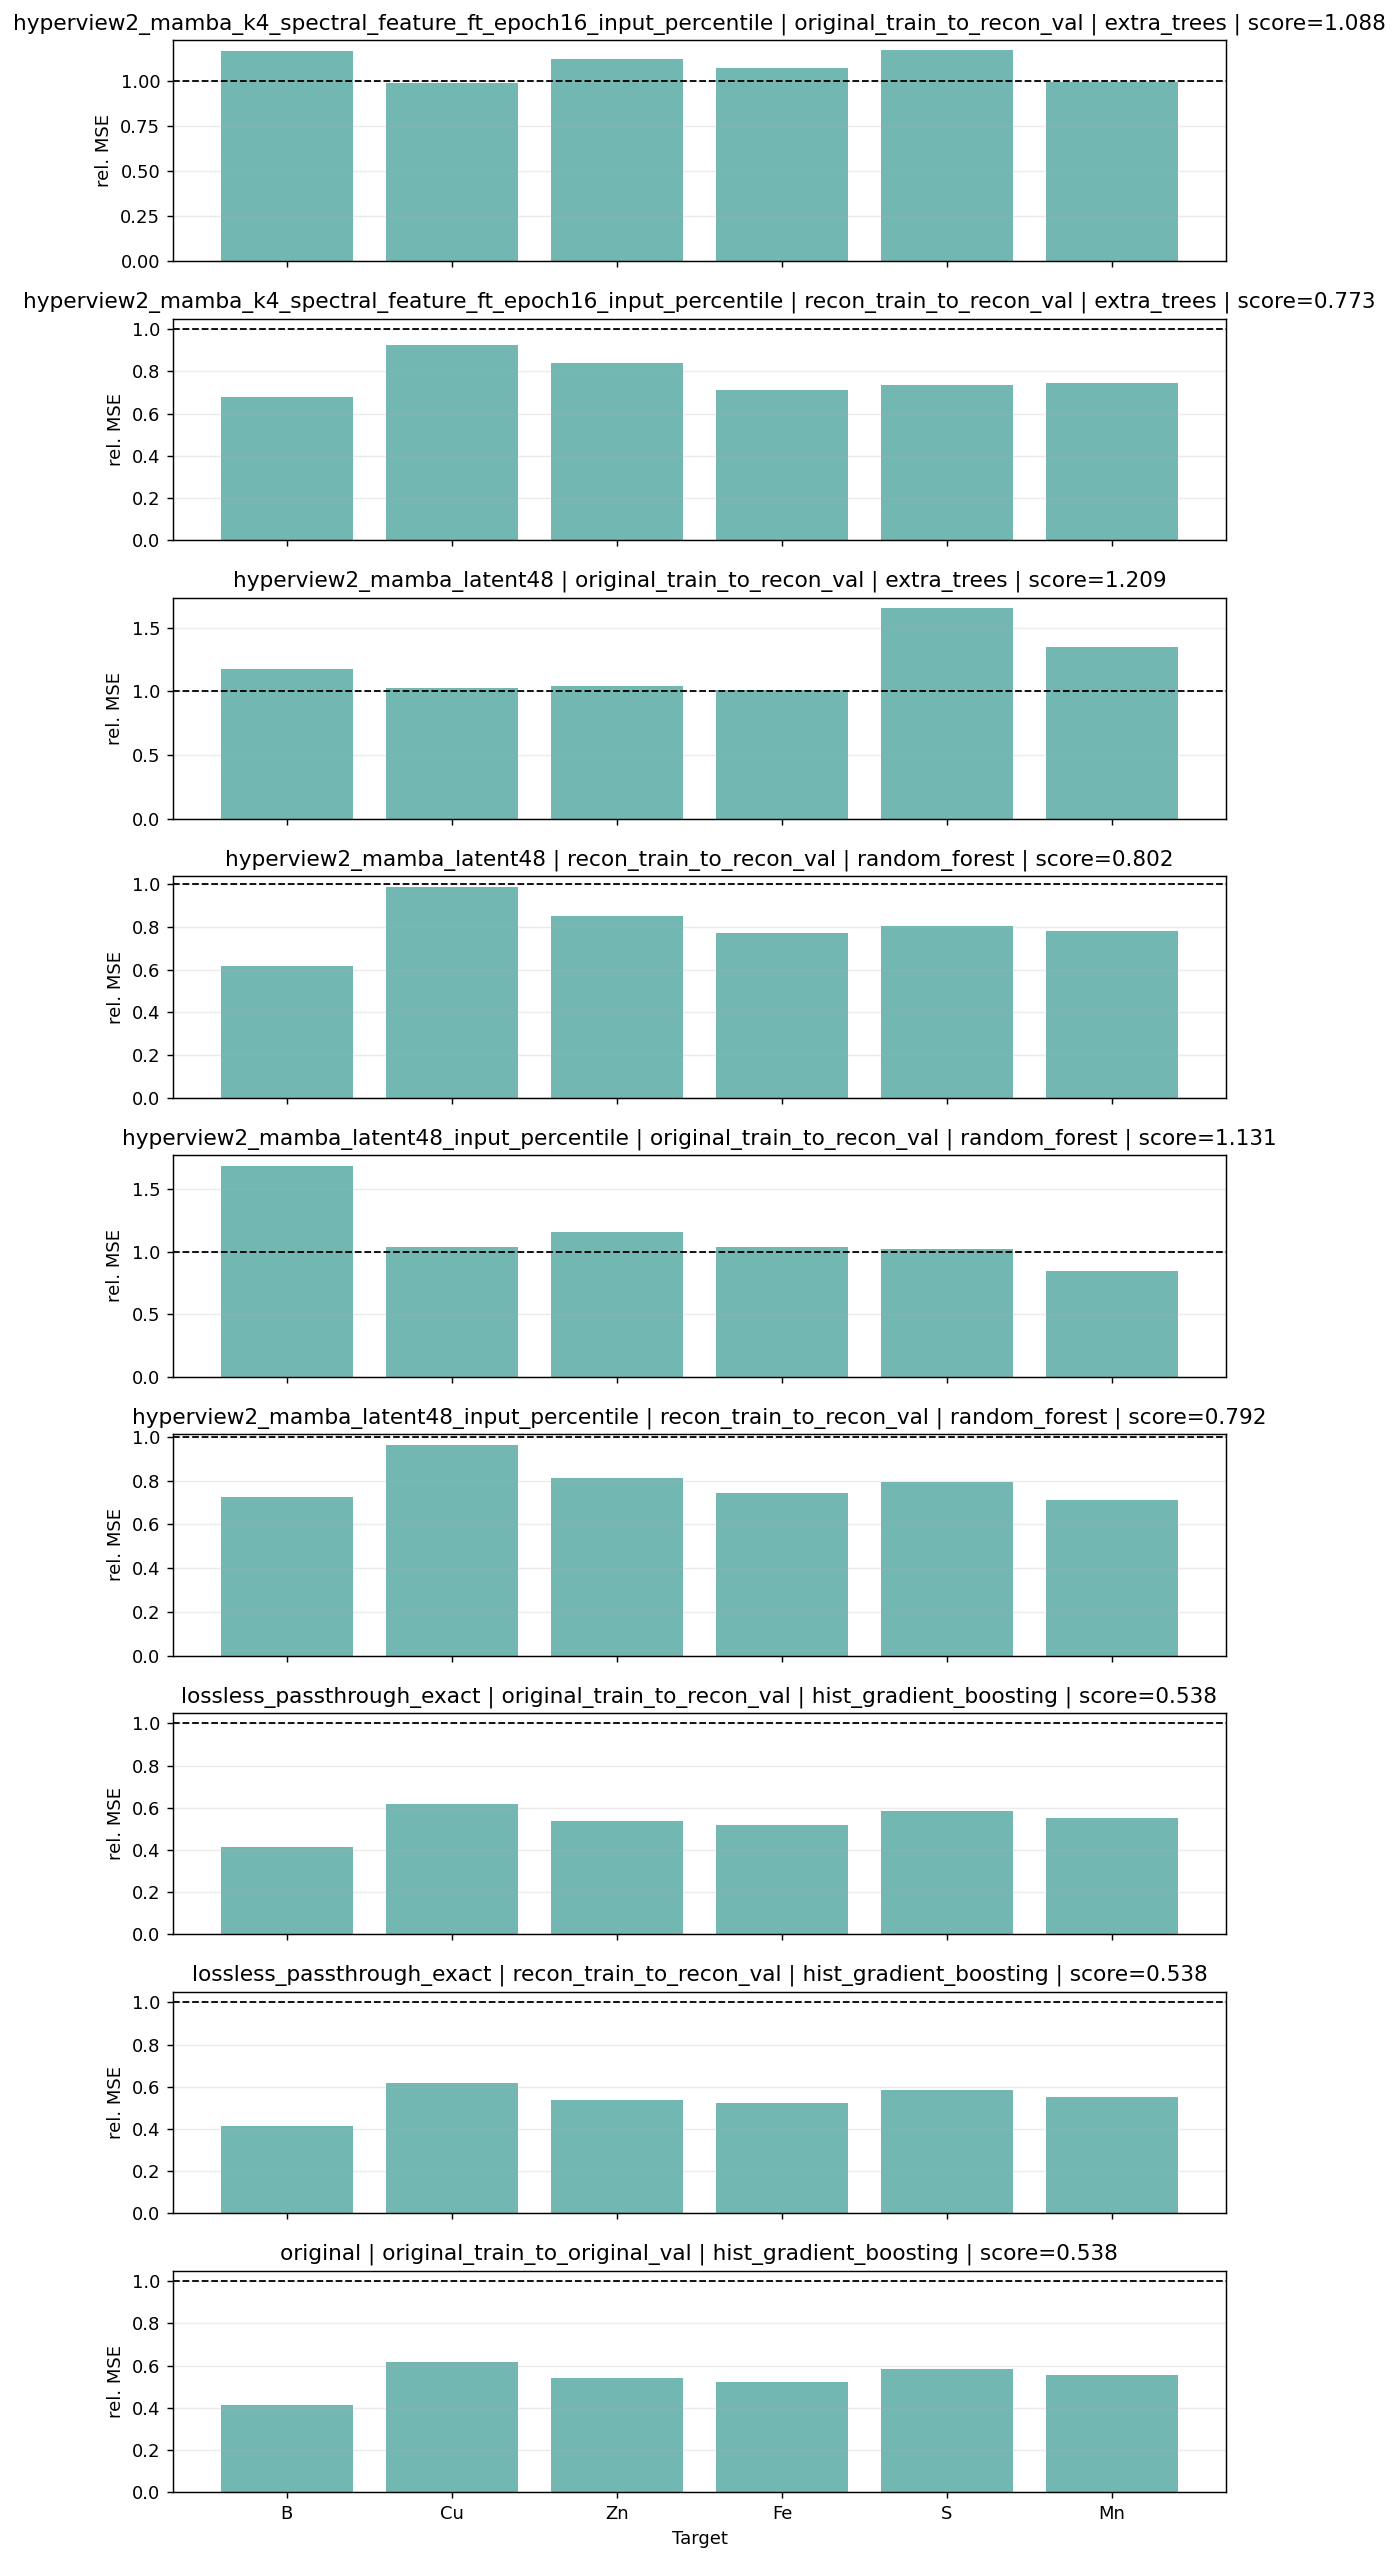

,variant,model,target,samples,original_mse,recon_mse,extra_mse,shift_mse,cross_term,mean_shift,mean_abs_shift,mean_extra_abs_error,mse_identity_residual
0,hyperview2_mamba_k4_spectral_feature_ft_epoch1...,extra_trees,Fe,375,1570.683199,3499.636519,1928.953320,1813.921932,115.031388,16.844323,33.426070,17.753270,0.000000e+00
1,hyperview2_mamba_k4_spectral_feature_ft_epoch1...,extra_trees,Mn,375,288.589644,522.965100,234.375457,182.804198,51.571259,-3.623483,11.498197,5.276916,-1.136868e-13
2,hyperview2_mamba_k4_spectral_feature_ft_epoch1...,extra_trees,S,375,106.665809,206.877189,100.211380,82.784102,17.427279,-5.231490,7.793117,3.458849,-2.842171e-14
3,hyperview2_mamba_k4_spectral_feature_ft_epoch1...,extra_trees,Zn,375,2.363749,4.388362,2.024613,1.522744,0.501869,0.648772,1.081532,0.651761,0.000000e+00
4,hyperview2_mamba_k4_spectral_feature_ft_epoch1...,extra_trees,Cu,375,0.129674,0.188851,0.059177,0.036953,0.022224,-0.002207,0.150583,0.062322,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,lossless_passthrough_exact,random_forest,Cu,375,0.135240,0.135240,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
68,lossless_passthrough_exact,random_forest,Fe,375,1595.949277,1595.949277,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
69,lossless_passthrough_exact,random_forest,Mn,375,295.529162,295.529162,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
70,lossless_passthrough_exact,random_forest,S,375,109.557229,109.557229,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00


In [30]:
target_metrics = prediction_metrics_by_target(predictions_df)
shift_df = prediction_shift_decomposition(predictions_df)

target_metrics_path = DRIVE_RESULTS / 'prediction_metrics_by_target.csv'
shift_path = DRIVE_RESULTS / 'prediction_shift_decomposition.csv'
target_metrics.to_csv(target_metrics_path, index=False)
shift_df.to_csv(shift_path, index=False)
print('Saved:', target_metrics_path)
print('Saved:', shift_path)

best_keys = best_df[['variant', 'mode', 'model']]
focus_targets = target_metrics.merge(best_keys, on=['variant', 'mode', 'model'], how='inner')
display(focus_targets.sort_values(['variant', 'mode', 'relative_mse']).reset_index(drop=True))

if not focus_targets.empty:
    rows = list(best_df.itertuples(index=False))
    fig, axes = plt.subplots(len(rows), 1, figsize=(9, max(3, 2.2 * len(rows))), sharex=True)
    if len(rows) == 1:
        axes = [axes]
    for ax, row in zip(axes, rows):
        vals = [getattr(row, f'{target}_relative_mse', np.nan) for target in TARGETS]
        ax.bar(TARGETS, vals, color='#72b7b2')
        ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
        ax.set_ylabel('rel. MSE')
        ax.set_title(f'{row.variant} | {row.mode} | {row.model} | score={row.hyperview_score:.3f}')
        ax.grid(True, axis='y', alpha=0.25)
    axes[-1].set_xlabel('Target')
    fig.tight_layout()
    out = DRIVE_RESULTS / 'per_target_relative_mse_best_models.png'
    fig.savefig(out, bbox_inches='tight')
    print('Saved:', out)
    plt.show()

display(shift_df.sort_values(['variant', 'model', 'extra_mse'], ascending=[True, True, False]).reset_index(drop=True))

## 9. Diagnostyka pasm: MAE, bias i najgorsze bandy

per-band:hyperview2_mamba_k4_spectral_feature_ft_epoch16_input_percentile:   0%|          | 0/375 [00:00<?, ?i…

per-band:hyperview2_mamba_latent48:   0%|          | 0/375 [00:00<?, ?it/s]

per-band:hyperview2_mamba_latent48_input_percentile:   0%|          | 0/375 [00:00<?, ?it/s]

per-band:hyperview2:   0%|          | 0/375 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/hsi/downstream_results/hyperview2_compression_hyspecnet_norm/per_band_diagnostics.csv
Saved: /content/drive/MyDrive/hsi/downstream_results/hyperview2_compression_hyspecnet_norm/sample_reconstruction_errors.csv


,variant,original_normalization,mae,rmse,bias
0,hyperview2_mamba_k4_spectral_feature_ft_epoch1...,percentile,0.307642,0.330198,-0.195453
1,hyperview2_mamba_latent48,none,0.238762,0.247676,0.216025
2,hyperview2_mamba_latent48_input_percentile,percentile,0.038482,0.054138,-0.006806
3,lossless_passthrough_exact,reflectance_0_1,0.000000,0.000000,0.000000


,variant,band,mae,rmse,bias,orig_mean,recon_mean
0,hyperview2_mamba_k4_spectral_feature_ft_epoch1...,91,0.552708,0.558624,-0.552708,0.995166,0.442458
1,hyperview2_mamba_k4_spectral_feature_ft_epoch1...,92,0.540147,0.547275,-0.540147,0.971685,0.431539
2,hyperview2_mamba_k4_spectral_feature_ft_epoch1...,90,0.520624,0.525270,-0.520624,0.992290,0.471666
3,hyperview2_mamba_k4_spectral_feature_ft_epoch1...,89,0.515913,0.523175,-0.515913,0.967593,0.451680
4,hyperview2_mamba_k4_spectral_feature_ft_epoch1...,88,0.470715,0.478568,-0.470715,0.924681,0.453966
5,hyperview2_mamba_k4_spectral_feature_ft_epoch1...,93,0.469934,0.475988,-0.469934,0.921864,0.451929
6,hyperview2_mamba_k4_spectral_feature_ft_epoch1...,84,0.462012,0.470311,-0.462012,0.928403,0.466391
7,hyperview2_mamba_k4_spectral_feature_ft_epoch1...,87,0.460193,0.468104,-0.460193,0.921294,0.461101
8,hyperview2_mamba_k4_spectral_feature_ft_epoch1...,169,0.459131,0.505056,-0.435547,0.749262,0.313714
9,hyperview2_mamba_k4_spectral_feature_ft_epoch1...,86,0.456024,0.464099,-0.456024,0.918969,0.462945


Saved: /content/drive/MyDrive/hsi/downstream_results/hyperview2_compression_hyspecnet_norm/per_band_error_curves.png


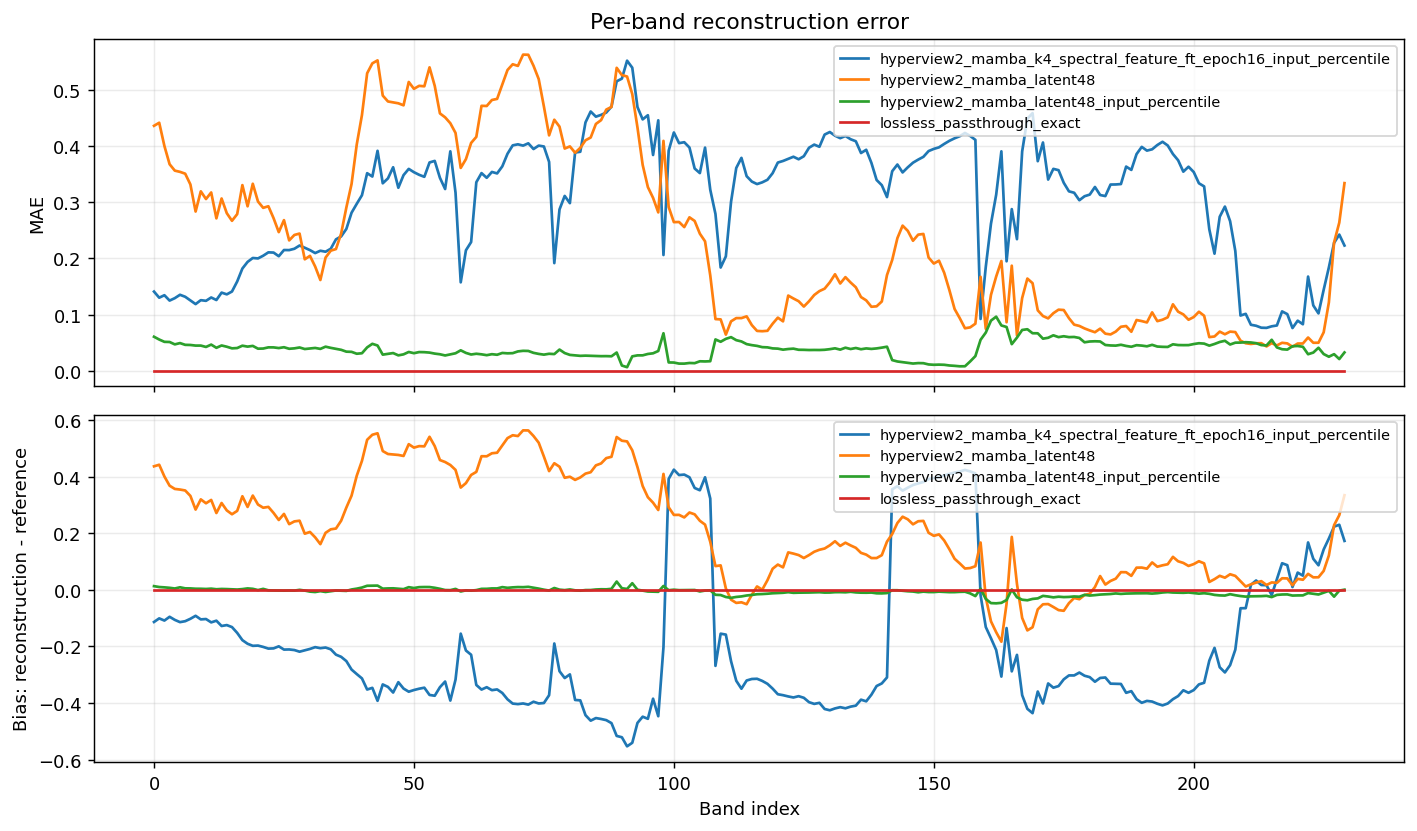

Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [31]:
val_ids = [str(item) for item in metrics_payload['protocol']['val_sample_ids']]
per_band_tables = []
sample_error_tables = []

for variant, root in RECON_ROOTS.items():
    original_norm = RECON_INPUT_NORMALIZATIONS.get(variant, 'none')
    per_band, sample_errors = compute_per_band_diagnostics(
        original_root=HV2_ROOT,
        recon_root=root,
        sample_ids=val_ids,
        original_normalization=original_norm,
        max_samples=MAX_PER_BAND_SAMPLES,
    )
    per_band['variant'] = variant
    sample_errors['variant'] = variant
    per_band_tables.append(per_band)
    sample_error_tables.append(sample_errors)

per_band_df = pd.concat(per_band_tables, ignore_index=True) if per_band_tables else pd.DataFrame()
sample_errors_df = pd.concat(sample_error_tables, ignore_index=True) if sample_error_tables else pd.DataFrame()
per_band_path = DRIVE_RESULTS / 'per_band_diagnostics.csv'
sample_errors_path = DRIVE_RESULTS / 'sample_reconstruction_errors.csv'
per_band_df.to_csv(per_band_path, index=False)
sample_errors_df.to_csv(sample_errors_path, index=False)
print('Saved:', per_band_path)
print('Saved:', sample_errors_path)

display(per_band_df.groupby(['variant', 'original_normalization'])[['mae', 'rmse', 'bias']].mean().reset_index())

top_bands = (
    per_band_df.sort_values(['variant', 'mae'], ascending=[True, False])
    .groupby('variant')
    .head(12)
    [['variant', 'band', 'mae', 'rmse', 'bias', 'orig_mean', 'recon_mean']]
)
display(top_bands.reset_index(drop=True))

if not per_band_df.empty:
    fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)
    for variant, group in per_band_df.groupby('variant'):
        axes[0].plot(group['band'], group['mae'], label=variant)
        axes[1].plot(group['band'], group['bias'], label=variant)
    axes[0].set_ylabel('MAE')
    axes[0].set_title('Per-band reconstruction error')
    axes[1].set_ylabel('Bias: reconstruction - reference')
    axes[1].set_xlabel('Band index')
    for ax in axes:
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8)
    fig.tight_layout()
    out = DRIVE_RESULTS / 'per_band_error_curves.png'
    fig.savefig(out, bbox_inches='tight')
    print('Saved:', out)
    plt.show()

## 10. Interaktywna analiza widm i obrazow pasm

In [32]:
import ipywidgets as widgets
from IPython.display import display


def mean_spectrum(cube: np.ndarray, mask: np.ndarray) -> np.ndarray:
    counts = mask.sum(axis=(1, 2)).astype(np.float32)
    values = (cube * mask).sum(axis=(1, 2)).astype(np.float32)
    out = np.full(cube.shape[0], np.nan, dtype=np.float32)
    np.divide(values, counts, out=out, where=counts > 0)
    return out


def load_original_recon_pair(variant: str, sample_id: str):
    root = RECON_ROOTS[variant]
    original_norm = RECON_INPUT_NORMALIZATIONS.get(variant, 'none')
    orig, orig_mask = load_cube_and_value_mask(sample_path(HV2_ROOT, sample_id))
    recon, recon_mask = load_cube_and_value_mask(sample_path(root, sample_id))
    orig = normalize_original_cube(orig, orig_mask, original_norm)
    c = min(orig.shape[0], recon.shape[0])
    h = min(orig.shape[-2], recon.shape[-2])
    w = min(orig.shape[-1], recon.shape[-1])
    orig = orig[:c, :h, :w]
    recon = recon[:c, :h, :w]
    valid = orig_mask[:c, :h, :w] & recon_mask[:c, :h, :w]
    return orig, recon, valid, original_norm


variant_widget = widgets.Dropdown(options=list(RECON_ROOTS), description='variant')
sample_widget = widgets.Dropdown(options=val_ids, description='sample')
band_widget = widgets.IntSlider(value=0, min=0, max=229, step=1, description='band')


def show_reconstruction(variant: str, sample_id: str, band: int):
    orig, recon, valid, original_norm = load_original_recon_pair(variant, sample_id)
    band = int(np.clip(band, 0, orig.shape[0] - 1))
    orig_spec = mean_spectrum(orig, valid)
    recon_spec = mean_spectrum(recon, valid)
    diff_spec = recon_spec - orig_spec
    valid_band = valid[band]
    mae = float(np.abs((recon - orig)[valid]).mean()) if valid.any() else np.nan
    rmse = float(np.sqrt(((recon - orig)[valid] ** 2).mean())) if valid.any() else np.nan

    print(f'variant={variant} | sample={sample_id} | original_norm={original_norm} | MAE={mae:.6f} | RMSE={rmse:.6f}')
    fig, axes = plt.subplots(2, 2, figsize=(11, 7))
    x = np.arange(orig.shape[0])
    axes[0, 0].plot(x, orig_spec, label='original/reference', linewidth=1.4)
    axes[0, 0].plot(x, recon_spec, label='reconstruction', linewidth=1.2)
    axes[0, 0].axvline(band, color='black', linestyle='--', linewidth=0.8)
    axes[0, 0].set_title('Mean spectrum')
    axes[0, 0].set_xlabel('Band')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.25)

    axes[1, 0].plot(x, diff_spec, color='#e45756')
    axes[1, 0].axhline(0.0, color='black', linewidth=0.8)
    axes[1, 0].axvline(band, color='black', linestyle='--', linewidth=0.8)
    axes[1, 0].set_title('Mean spectral error')
    axes[1, 0].set_xlabel('Band')
    axes[1, 0].grid(True, alpha=0.25)

    vmin = float(np.nanpercentile(orig[band][valid_band], 1)) if valid_band.any() else None
    vmax = float(np.nanpercentile(orig[band][valid_band], 99)) if valid_band.any() else None
    axes[0, 1].imshow(orig[band], cmap='viridis', vmin=vmin, vmax=vmax)
    axes[0, 1].set_title(f'Original/reference band {band}')
    axes[0, 1].axis('off')

    err = recon[band] - orig[band]
    lim = float(np.nanpercentile(np.abs(err[valid_band]), 99)) if valid_band.any() else 1.0
    axes[1, 1].imshow(err, cmap='coolwarm', vmin=-lim, vmax=lim)
    axes[1, 1].set_title(f'Reconstruction error band {band}')
    axes[1, 1].axis('off')
    fig.tight_layout()
    plt.show()


ui = widgets.VBox([variant_widget, sample_widget, band_widget])
out = widgets.interactive_output(
    show_reconstruction,
    {'variant': variant_widget, 'sample_id': sample_widget, 'band': band_widget},
)
display(ui, out)

Output()

## 11. Pliki wyjsciowe

In [33]:
print('Results directory:', DRIVE_RESULTS)
for path in sorted(DRIVE_RESULTS.glob('*')):
    if path.is_file():
        print(path.name, f'{path.stat().st_size / 1024:.1f} KiB')

Results directory: /content/drive/MyDrive/hsi/downstream_results/hyperview2_compression_hyspecnet_norm
best_downstream_scores.png 124.6 KiB
best_scores.csv 4.5 KiB
compression_downstream_metrics.json 114.0 KiB
compression_downstream_predictions.csv 15453.6 KiB
compression_downstream_summary.csv 12.5 KiB
per_band_diagnostics.csv 133.5 KiB
per_band_error_curves.png 225.6 KiB
per_target_relative_mse_best_models.png 222.5 KiB
prediction_metrics_by_target.csv 28.9 KiB
prediction_shift_decomposition.csv 14.4 KiB
sample_reconstruction_errors.csv 132.9 KiB
